In [1]:
import pathlib
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pingouin as pg
import pickle

 
import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig3_sparseKO_place_fields')
figdir.mkdir(exist_ok=True, parents=True)

In [5]:
import pickle 
with open('/home/mplitt/shuffle_pkls/sparse_place_field_spatial_shuffle_spks.pkl','rb') as file:
    shuff_results = pickle.load(file)

In [6]:
df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'n_fields': []}
for mouse in sparse_mice:
    for day in range(6):
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):
               
                rising_edges = shuff_results[mouse][chan][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][chan][day][nov]['falling_edges']
                widths = shuff_results[mouse][chan][day][nov]['field_widths']
                
                mask = (widths>1) * (widths<25)  #* (rising_edges[:,1]>0) * (falling_edges[:,1]<29)
              

                n_fields = np.bincount(rising_edges[mask,0])
                
        
                n_fields = n_fields[n_fields>0]

                for n in n_fields:
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['chan'].append(chan)
                    df['n_fields'].append(n)

df = pd.DataFrame.from_dict(df)
        

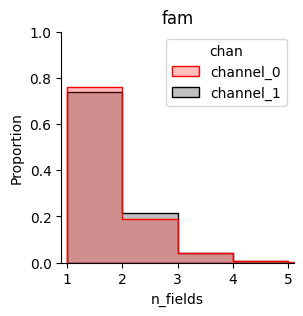

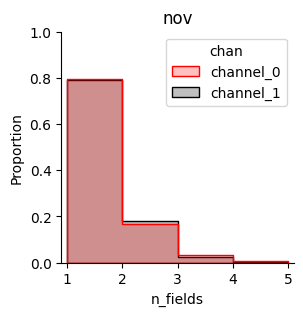

In [7]:
for nov in ('fam', 'nov'):

    fig,ax = plt.subplots(figsize=[3,3])
    sns.histplot(data=df.loc[df['nov']==nov,:], x='n_fields', hue='chan', cumulative=False, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
                binwidth=1., fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    ax.set_ylim([0,1])
    ax.set_xlim([.9,5.1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)

    # fig.savefig(figdir / f'n_fields_hist_{nov}.pdf', bbox_inches='tight')



Text(0.5, 1.0, 'combined')

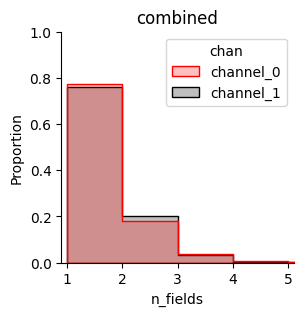

In [8]:
fig,ax = plt.subplots(figsize=[3,3])
sns.histplot(data=df, x='n_fields', hue='chan', cumulative=False, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
            binwidth=1., fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
ax.set_ylim([0,1])
ax.set_xlim([.9,5.1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('combined')

# fig.savefig(figdir / f'n_fields_hist_combined.pdf', bbox_inches='tight')

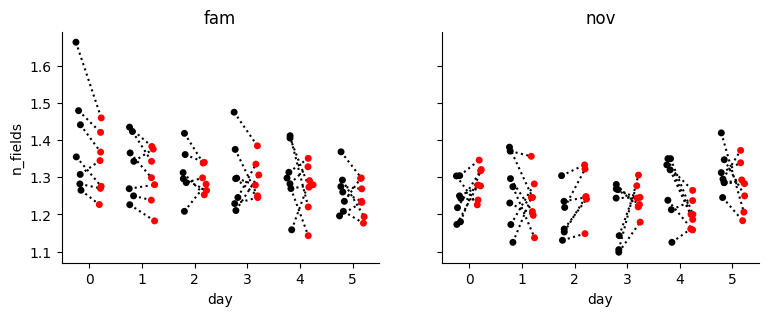

In [9]:
df_mu = df.groupby(['mouse','day','chan','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey=True)
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='n_fields',
                hue='chan', 
                hue_order=('channel_1', 'channel_0'), 
                palette=['black', 'red'],
                dodge=True,
                ax=ax[i],
                legend=False)
    ax[i].set_title(nov)



    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    
# fig.savefig( figdir / 'n_fields_per_day.pdf', bbox_inches='tight')

Text(0.5, 1.0, 'combined')

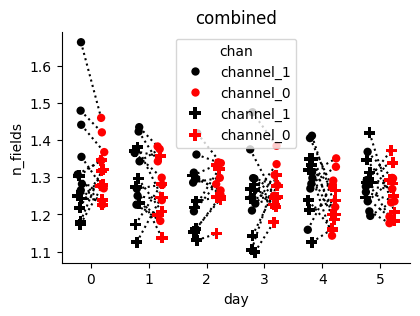

In [10]:
df_mu = df.groupby(['mouse','day','chan','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(figsize=[4.5,3], sharey=True)

sns.stripplot(data=df_mu.loc[df_mu['nov']=='fam',:],
            x='day',
            y='n_fields',
            hue='chan', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax,
            s=6,
            legend=True)

# for d in range(0,12,2):
#     for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
#         ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


sns.stripplot(data=df_mu.loc[df_mu['nov']=='nov',:],
            x='day',
            y='n_fields',
            hue='chan',
            hue_order=('channel_1', 'channel_0'),
            palette=['black', 'red'],
            dodge=True,
            ax=ax,
            marker='P',
            alpha=1.,
            s=8,
            legend=True)


ax.set_title(nov)



for d in range(0,24,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('combined')
# ax.set_ylim([1,1.5])
    
# fig.savefig( figdir / 'n_fields_per_day_combined.pdf', bbox_inches='tight')

In [11]:
with open('/home/mplitt/shuffle_pkls/sparse_n_fields_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']

    p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
    print(f"{stat} true coef = {true_coef}, p = {p} ")


n_fields true coef = 0.019201472346692162, p = 0.293 
rank_n_fields true coef = 163.83694124090223, p = 0.122 


In [12]:
model_shuff_results['rank_n_fields']['true_model'].summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Mixed Linear Model Regression Results
=======================================================================================
Model:                      MixedLM          Dependent Variable:          rank_n_fields
No. Observations:           12856            Method:                      REML         
No. Groups:                 7                Scale:                       5751733.9346 
Min. group size:            1338             Log-Likelihood:              -118151.1901 
Max. group size:            2815             Converged:                   Yes          
Mean group size:            1836.6                                                     
---------------------------------------------------------------------------------------
                                        Coef.   Std.Err.   z    P>|z|  [0.025   0.975] 
---------------------------------------------------------------------------------------
Intercept                              6666.849   83.463 79.878 0.000 6503.264 6830.433
chan[T.channel_1]                       163.837  139.561  1.174 0.240 -109.698  437.371
day[T.1]                                -87.111  106.328 -0.819 0.413 -295.510  121.288
day[T.2]                                -94.751  109.702 -0.864 0.388 -309.763  120.262
day[T.3]                               -132.320  108.094 -1.224 0.221 -344.179   79.540
day[T.4]                               -282.966  107.566 -2.631 0.009 -493.791  -72.140
day[T.5]                               -541.061  116.635 -4.639 0.000 -769.661 -312.461
nov[T.nov]                             -317.093  129.748 -2.444 0.015 -571.394  -62.793
chan[T.channel_1]:day[T.1]               90.151  196.380  0.459 0.646 -294.746  475.048
chan[T.channel_1]:day[T.2]              125.608  205.832  0.610 0.542 -277.814  529.031
chan[T.channel_1]:day[T.3]               38.410  196.912  0.195 0.845 -347.531  424.350
chan[T.channel_1]:day[T.4]              -39.010  199.085 -0.196 0.845 -429.209  351.190
chan[T.channel_1]:day[T.5]               32.569  208.344  0.156 0.876 -375.777  440.915
chan[T.channel_1]:nov[T.nov]           -406.515  236.634 -1.718 0.086 -870.308   57.279
day[T.1]:nov[T.nov]                     -85.252  179.805 -0.474 0.635 -437.663  267.160
day[T.2]:nov[T.nov]                     -54.921  186.261 -0.295 0.768 -419.986  310.143
day[T.3]:nov[T.nov]                      45.308  184.394  0.246 0.806 -316.098  406.715
day[T.4]:nov[T.nov]                     119.167  184.291  0.647 0.518 -242.036  480.371
day[T.5]:nov[T.nov]                     513.171  181.229  2.832 0.005  157.969  868.373
chan[T.channel_1]:day[T.1]:nov[T.nov]   137.654  323.447  0.426 0.670 -496.291  771.599
chan[T.channel_1]:day[T.2]:nov[T.nov]   213.567  343.030  0.623 0.534 -458.760  885.894
chan[T.channel_1]:day[T.3]:nov[T.nov]    79.748  330.916  0.241 0.810 -568.836  728.332
chan[T.channel_1]:day[T.4]:nov[T.nov]   244.069  333.045  0.733 0.464 -408.687  896.826
chan[T.channel_1]:day[T.5]:nov[T.nov]   514.651  323.910  1.589 0.112 -120.200 1149.503
Group Var                             10160.805    3.209                               
=======================================================================================

"""

In [13]:
model_shuff_results['rank_n_fields']['true_model'].wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                chi2                P>chi2  df constraint
Intercept      [[6380.497858037696]]                   0.0              1
chan          [[1.3781474093204595]]   0.24041696310513638              1
day           [[26.639055228688314]]  6.70558137971485e-05              5
nov             [[5.97277679964891]]  0.014528385512655024              1
chan:day      [[0.8447214884458074]]    0.9740936071266584              5
chan:nov      [[2.9512078422440635]]   0.08581340027831073              1
day:nov       [[14.986670583452115]]  0.010419444532661686              5
chan:day:nov  [[3.1252564212229874]]    0.6806820013747388              5

# field width comparison

In [14]:
df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'width': []}
for mouse in sparse_mice:
    for day in range(6):
        
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):
                rising_edges = shuff_results[mouse][chan][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][chan][day][nov]['falling_edges']
                widths = shuff_results[mouse][chan][day][nov]['field_widths']
                
                mask = (widths>1) * (widths<25) * (rising_edges[:,1]>0) * (falling_edges[:,1]<29)
                widths = widths[mask]

                for w in widths:
                   
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['chan'].append(chan)
                    df['width'].append(10*w)

df = pd.DataFrame.from_dict(df)

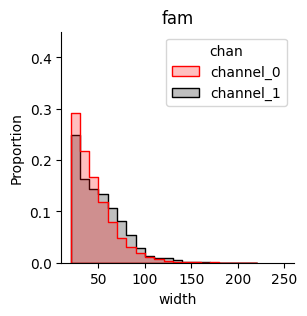

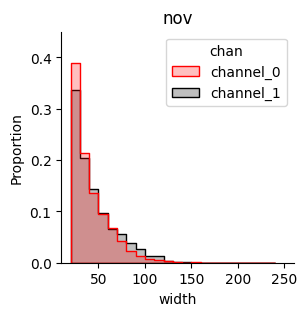

In [15]:

for nov in ('fam', 'nov'):
    fig,ax = plt.subplots(figsize=[3,3])

    sns.histplot(data=df.loc[df['nov']==nov,:], 
                 x='width', 
                 hue='chan', 
                 cumulative=False, 
                 hue_order=('channel_0', 'channel_1'), 
                 palette=['red', 'black'],
                 binwidth=10, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    
    ax.set_xlim([10,260])
    ax.set_ylim([0,.45])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)

    # fig.savefig(figdir / f'field_widths_hist_{nov}.pdf', bbox_inches='tight')


Text(0.5, 1.0, 'combined')

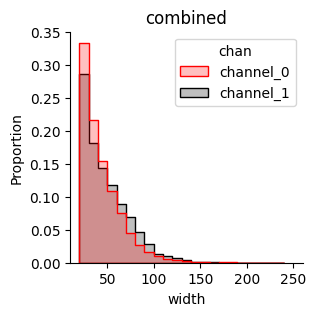

In [16]:

fig,ax = plt.subplots(figsize=[3,3])

sns.histplot(data=df, 
            x='width', 
            hue='chan', 
            cumulative=False, 
            hue_order=('channel_0', 'channel_1'), 
            palette=['red', 'black'],
            binwidth=10, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)

ax.set_xlim([10,260])
ax.set_ylim([0,.35])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('combined')

# fig.savefig(figdir / f'field_widths_hist_combined.pdf', bbox_inches='tight')


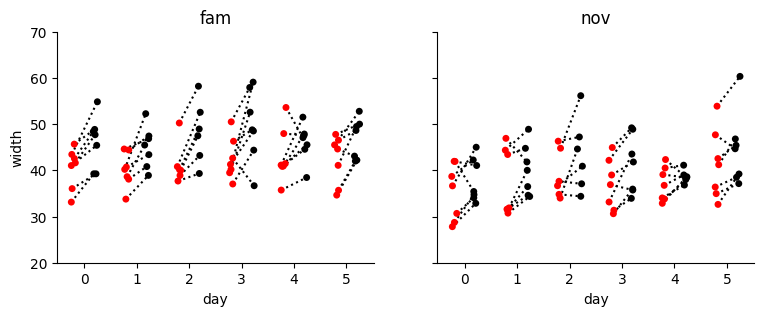

In [17]:
df_mu = df.groupby(['mouse','day','chan','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey=True)
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='width',
                hue='chan', 
                hue_order=('channel_0', 'channel_1'), 
                palette=['red', 'black'],
                dodge=.2,
                ax=ax[i],
                legend=False)
    ax[i].set_title(nov)
    ax[i].set_ylim([20,70])

    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

# fig.savefig( figdir / 'field_widths_per_day.pdf', bbox_inches='tight')

(20.0, 70.0)

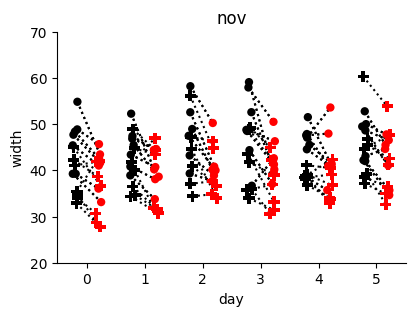

In [18]:
df_mu = df.groupby(['mouse','day','chan','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(figsize=[4.5,3], sharey=True)

sns.stripplot(data=df_mu.loc[df_mu['nov']=='fam',:],
            x='day',
            y='width',
            hue='chan', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax, s=6,
            legend=False)

# for d in range(0,12,2):
#     for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
#         ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


sns.stripplot(data=df_mu.loc[df_mu['nov']=='nov',:],
            x='day',
            y='width',
            hue='chan',
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax,
            marker='P',
            alpha=1.,
            s=8,
            legend=False)


ax.set_title(nov)



for d in range(0,24,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


for d in range(0,12,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([20,70])

# fig.savefig( figdir / 'field_widths_per_day_combined.pdf', bbox_inches='tight')

In [17]:
with open('/home/mplitt/shuffle_pkls/sparse_width_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']

    p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
    print(f"{stat} true coef = {true_coef}, p = {p} ")


width true coef = 5.616289263931416, p = 0.0 
rank_width true coef = 820.307073599806, p = 0.0 


In [18]:
model_shuff_results['rank_width']['true_model'].summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Mixed Linear Model Regression Results
=========================================================================================
Model:                      MixedLM           Dependent Variable:           rank_width   
No. Observations:           12127             Method:                       REML         
No. Groups:                 7                 Scale:                        11040408.9716
Min. group size:            1234              Log-Likelihood:               -115396.5929 
Max. group size:            2643              Converged:                    Yes          
Mean group size:            1732.4                                                       
-----------------------------------------------------------------------------------------
                                        Coef.    Std.Err.   z    P>|z|   [0.025   0.975] 
-----------------------------------------------------------------------------------------
Intercept                               6051.195  260.977 23.187 0.000  5539.688 6562.701
chan[T.channel_1]                        820.307  193.762  4.234 0.000   440.540 1200.074
day[T.1]                                -208.170  147.659 -1.410 0.159  -497.575   81.236
day[T.2]                                  16.590  154.034  0.108 0.914  -285.310  318.490
day[T.3]                                 175.169  151.382  1.157 0.247  -121.533  471.871
day[T.4]                                 359.453  152.594  2.356 0.018    60.374  658.533
day[T.5]                                 329.111  166.918  1.972 0.049     1.958  656.265
nov[T.nov]                             -1300.400  179.822 -7.232 0.000 -1652.845 -947.956
chan[T.channel_1]:day[T.1]               244.973  275.320  0.890 0.374  -294.643  784.589
chan[T.channel_1]:day[T.2]               160.998  290.080  0.555 0.579  -407.549  729.545
chan[T.channel_1]:day[T.3]               120.847  276.281  0.437 0.662  -420.655  662.349
chan[T.channel_1]:day[T.4]              -111.523  284.640 -0.392 0.695  -669.408  446.362
chan[T.channel_1]:day[T.5]                -3.403  296.627 -0.011 0.991  -584.781  577.975
chan[T.channel_1]:nov[T.nov]             262.804  333.898  0.787 0.431  -391.623  917.231
day[T.1]:nov[T.nov]                      665.320  250.922  2.652 0.008   173.522 1157.119
day[T.2]:nov[T.nov]                      905.481  262.361  3.451 0.001   391.263 1419.699
day[T.3]:nov[T.nov]                      394.314  258.537  1.525 0.127  -112.408  901.037
day[T.4]:nov[T.nov]                      530.962  261.600  2.030 0.042    18.236 1043.688
day[T.5]:nov[T.nov]                     1041.236  257.273  4.047 0.000   536.990 1545.482
chan[T.channel_1]:day[T.1]:nov[T.nov]   -582.426  458.257 -1.271 0.204 -1480.594  315.741
chan[T.channel_1]:day[T.2]:nov[T.nov]   -531.811  490.371 -1.085 0.278 -1492.921  429.299
chan[T.channel_1]:day[T.3]:nov[T.nov]   -315.442  469.180 -0.672 0.501 -1235.017  604.133
chan[T.channel_1]:day[T.4]:nov[T.nov]   -465.582  479.914 -0.970 0.332 -1406.196  475.032
chan[T.channel_1]:day[T.5]:nov[T.nov]   -587.322  463.365 -1.268 0.205 -1495.500  320.857
Group Var                             403971.476   71.426                                
=========================================================================================

"""

In [19]:
model_shuff_results['rank_width']['true_model'].wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                chi2                  P>chi2  df constraint
Intercept      [[537.6212846174516]]  6.207534153969368e-119              1
chan          [[17.923122705928446]]  2.3000960588113108e-05              1
day           [[18.426090118012876]]   0.0024571784628913246              5
nov           [[52.296079236467016]]   4.773265214096572e-13              1
chan:day       [[2.036891372460013]]      0.8440172287193137              5
chan:nov      [[0.6194960441697667]]      0.4312346207367814              1
day:nov        [[20.88867914871381]]   0.0008502387147832747              5
chan:day:nov  [[2.3355433423952494]]      0.8010326804042662              5